# Module 4: Volume Estimation from Segmented Images (NPY Mask Input)

This notebook estimates the volume of segmented food items using:
- **Segmentation masks** from Module 1 as **`.npy` files** (SAM / custom model output)
- **Volume per pixel** calibration from Module 3 (Thumb detection and calibration)

### Input format
Instead of YOLO `.txt` label files, this pipeline reads **numpy `.npy` mask files** directly.
Each `.npy` file contains a binary (or boolean) 2-D array where `True`/non-zero pixels mark the food region.

### Pipeline
```
.npy mask  →  load_npy_mask()  →  preprocess_mask()  →  mask_to_yolo_polygon()
           →  parse_npy_segments()  →  voxel-grid estimation  →  volume
```


## 1. Import Required Libraries

Import necessary libraries for image processing, data manipulation, and visualization.

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
import json
from typing import Tuple, Dict, Any
from scipy.optimize import linear_sum_assignment

# Set up matplotlib for better visualization
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Required libraries imported successfully!")

Required libraries imported successfully!


## Kaggle Setup Instructions

This notebook supports both **local** and **Kaggle** environments automatically.

### For Kaggle:
1. Upload your dataset with this structure:
   ```
   your-dataset/
   ├── segmentation_masks/
   │   ├── mask_01.png
   │   ├── mask_02.png
   │   └── ...
   ├── original_images/
   │   ├── image_01.jpg
   │   ├── image_02.jpg
   │   └── ...
   └── (calibration data if needed)
   ```

2. In your Kaggle notebook, add your dataset as input
3. The notebook will automatically detect Kaggle and use `/kaggle/input/your-dataset/` paths
4. Results will be saved to `/kaggle/working/`

### For Local Development:
- Create `segmentation_masks/` and `original_images/` folders in the same directory
- Run the notebook - it will automatically use local paths

The notebook automatically detects the environment and adjusts paths accordingly!

## Primary Input: NPY Segmentation Masks

This notebook reads **`.npy`** segmentation mask files produced by SAM or any other
segmentation model.  Each file contains a 2-D numpy array:

```
shape : (H, W)       — single-channel
dtype : bool | uint8 | float32
values: non-zero / True  → food pixel
        zero / False     → background
```

### Naming convention
Mask files are matched to images **by base filename**, e.g.:
```
images/image_beguni_1.jpg   ←→   masks/image_beguni_1_mask_000.npy
images/image_beguni_2.jpg   ←→   masks/image_beguni_2_mask_000.npy
```
If a single image contains **multiple food items**, supply multiple `.npy` files with
the same image prefix (e.g. `_mask_000.npy`, `_mask_001.npy`, …).


## 2. Setup: Configuration and Calibration

Define paths, calibration value, and helper functions for the complete workflow.

In [25]:
# ============================================================================
# CONFIGURATION: Paths and Calibration
# ============================================================================

IS_KAGGLE = os.path.exists('/kaggle/input')
PROJECT_ROOT = Path('.').resolve()

if IS_KAGGLE:
    print("🟢 Running on Kaggle")
    DATA_DIR   = "/kaggle/input/datasets/hillol123/module-4-custom-datasets"
    IMAGES_DIR = os.path.join(DATA_DIR, "images")
    MASKS_DIR  = os.path.join(DATA_DIR, "masks")   # folder with .npy mask files
    OUTPUT_DIR = "/kaggle/working"
else:
    print("🔵 Running locally")
    DATA_DIR   = str(PROJECT_ROOT)
    IMAGES_DIR = os.path.join(DATA_DIR, "input", "images")
    MASKS_DIR  = os.path.join(DATA_DIR, "masks")   # folder with .npy mask files
    OUTPUT_DIR = os.path.join(DATA_DIR, "output")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Calibration from Module 3 ─────────────────────────────────────────────
PIXEL_LENGTH_MM = 0.5    # real-world length of 1 pixel [mm]  ← adjust this!
VOXEL_SIZE_MM   = 5.0    # voxel side length [mm]

print(f"\n📊 Configuration:")
print(f"   Project root     : {DATA_DIR}")
print(f"   Images directory : {IMAGES_DIR}")
print(f"   Masks directory  : {MASKS_DIR}  (.npy files)")
print(f"   Output directory : {OUTPUT_DIR}")
print(f"   Pixel length     : {PIXEL_LENGTH_MM} mm/pixel")
print(f"   Voxel size       : {VOXEL_SIZE_MM} mm")

for d, label in [(IMAGES_DIR, 'Images'), (MASKS_DIR, 'Masks')]:
    if os.path.exists(d):
        print(f"\n✅ {label} directory found!")
    else:
        print(f"\n⚠️  {label} directory not found: {d}")


🔵 Running locally

📊 Configuration:
   Project root     : /media/rageeb-hasan-shafee/New Volume/Capstone Project
   Images directory : /media/rageeb-hasan-shafee/New Volume/Capstone Project/input/images
   Masks directory  : /media/rageeb-hasan-shafee/New Volume/Capstone Project/masks  (.npy files)
   Output directory : /media/rageeb-hasan-shafee/New Volume/Capstone Project/output
   Pixel length     : 0.5 mm/pixel
   Voxel size       : 5.0 mm

✅ Images directory found!

✅ Masks directory found!


## 2.1 Step 1: Load Image

Load an RGB image from disk.  `load_image_file()` accepts `.jpg`, `.png`, etc.


In [26]:
def load_image_file(image_path: str) -> np.ndarray:
    """
    Load RGB image from file path.
    
    Args:
        image_path: Path to image file (.jpg, .png, etc)
        
    Returns:
        numpy array: RGB image (3-channel)
    """
    if not os.path.exists(image_path):
        print(f"❌ Error: Image not found at {image_path}")
        return None
    
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Error: Could not read image {image_path}")
        return None
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print(f"✅ Loaded image: {image_path}")
    print(f"   Shape: {image.shape[1]}×{image.shape[0]} pixels")
    return image


# EXAMPLE: Load your image
# Modify the filename to match your actual image file
IMAGE_FILENAME = "image_input_2_side.jpg" # Change this!
image_path = os.path.join(IMAGES_DIR, IMAGE_FILENAME)

print("\n" + "="*60)
print("STEP 1: LOAD IMAGE")
print("="*60)
image = load_image_file(image_path)

if image is not None:
    print(f"✅ Image loaded successfully!")
else:
    print(f"⚠️  Update IMAGE_FILENAME to your actual filename")
    



STEP 1: LOAD IMAGE
✅ Loaded image: /media/rageeb-hasan-shafee/New Volume/Capstone Project/input/images/image_input_2_side.jpg
   Shape: 1536×2048 pixels
✅ Image loaded successfully!


## 2.2 Step 2: Load NPY Segmentation Mask

Read a `.npy` file and normalise it to a binary uint8 mask (0 / 255).
Multiple masks per image (multiple food items) are supported — just pass a list of paths.


In [27]:
# ─────────────────────────────────────────────────────────────────────
# NPY mask loading  (replaces YOLO .txt loading)
# ─────────────────────────────────────────────────────────────────────

def load_npy_mask(path: str) -> np.ndarray:
    """
    Load a numpy segmentation mask from a .npy file and normalise it
    to a binary uint8 mask (0 = background, 255 = food).

    The file may contain:
      - A boolean array  (True / False)
      - A uint8 array    (0 / 1  or  0 / 255)
      - A float array    (0.0 / 1.0)
      - A higher-dim array — squeezed to 2-D automatically

    Args:
        path: Path to the .npy file

    Returns:
        Binary mask (uint8, values 0 or 255), shape (H, W)

    Raises:
        FileNotFoundError if the file does not exist
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Mask file not found: {path}")

    data = np.load(path, allow_pickle=True)
    mask = np.asarray(data)

    # Squeeze extra dimensions (e.g. (1, H, W) → (H, W))
    if mask.ndim > 2:
        mask = np.squeeze(mask)

    # Normalise any dtype to binary uint8 (0 or 255)
    binary = (mask > 0).astype(np.uint8) * 255

    # Auto-correct inverted masks: food should be < 50% of the image.
    # SAM sometimes stores background=True, food=False — flip those.
    food_ratio = np.count_nonzero(binary) / max(binary.size, 1)
    if food_ratio > 0.50:
        binary = cv2.bitwise_not(binary)
        print(f"   ⚠️  Mask inverted ({food_ratio:.1%} marked) — auto-flipped")

    print(f"✅ Loaded mask: {path}")
    print(f"   Shape: {binary.shape}, Food pixels: {np.count_nonzero(binary):,}")
    return binary


def mask_to_yolo_polygon(
    mask: np.ndarray,
    image_width: int,
    image_height: int,
    epsilon_ratio: float = 0.002,
) -> list:
    """
    Convert a binary mask to normalised YOLO polygon coordinates.

    Finds the largest contour in the mask, simplifies it with
    Douglas-Peucker (epsilon = epsilon_ratio × arc length), then
    normalises x/y to the range [0, 1].

    Args:
        mask          : Binary mask (uint8, 0/255), any spatial size
        image_width   : Target image width  (pixels)
        image_height  : Target image height (pixels)
        epsilon_ratio : Contour simplification aggressiveness (0.001–0.01)

    Returns:
        List of (x_norm, y_norm) tuples — empty list if no contour found
    """
    # Resize mask to match the image if dimensions differ
    if mask.shape[:2] != (image_height, image_width):
        mask = cv2.resize(mask, (image_width, image_height),
                          interpolation=cv2.INTER_NEAREST)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return []

    largest = max(contours, key=cv2.contourArea)
    epsilon  = epsilon_ratio * cv2.arcLength(largest, True)
    approx   = cv2.approxPolyDP(largest, epsilon, True)

    return [(pt[0][0] / image_width, pt[0][1] / image_height) for pt in approx]


def coordinates_to_mask(
    img_height: int,
    img_width: int,
    normalized_coords: list,
) -> np.ndarray:
    """
    Convert normalised YOLO polygon coordinates → binary mask (uint8, 0/255).
    (Kept for compatibility with parse_npy_segments below.)
    """
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    if not normalized_coords:
        return mask
    pixel_coords = np.array(
        [[int(x * img_width), int(y * img_height)] for x, y in normalized_coords],
        dtype=np.int32,
    )
    cv2.fillPoly(mask, [pixel_coords], 255)
    return mask


# ── Example: load a single mask ──────────────────────────────────────────
print("\n" + "="*60)
print("STEP 2: LOAD NPY SEGMENTATION MASK")
print("="*60)
print("  ℹ️  Update the paths below to your actual .npy mask files")
print("  Then the mask will be loaded and ready for Step 3.")
print()
print("  Example:")
print("    mask1 = load_npy_mask(os.path.join(MASKS_DIR, 'input_2_top_mask_001.npy'))")
print("    mask2 = load_npy_mask(os.path.join(MASKS_DIR, 'input_2_side_mask_001.npy'))")
# print("    mask3 = load_npy_mask(os.path.join(MASKS_DIR, 'input_1_top_mask_002.npy'))")

# Auto-load the first available mask for quick Step 4 visualization
mask_files = sorted([f for f in os.listdir(MASKS_DIR) if f.lower().endswith('.npy')]) if os.path.exists(MASKS_DIR) else []
if mask_files:
    mask_path = os.path.join(MASKS_DIR, mask_files[0])
    mask = load_npy_mask(mask_path)
    mask1 = mask  # keep a convenient alias used in later steps
    print(f"\n✅ Auto-loaded mask for visualization: {mask_files[0]}")
else:
    print("\n⚠️  No .npy files found in MASKS_DIR")



STEP 2: LOAD NPY SEGMENTATION MASK
  ℹ️  Update the paths below to your actual .npy mask files
  Then the mask will be loaded and ready for Step 3.

  Example:
    mask1 = load_npy_mask(os.path.join(MASKS_DIR, 'input_2_top_mask_001.npy'))
    mask2 = load_npy_mask(os.path.join(MASKS_DIR, 'input_2_side_mask_001.npy'))
✅ Loaded mask: /media/rageeb-hasan-shafee/New Volume/Capstone Project/masks/input_2_side_mask_001.npy
   Shape: (1280, 960), Food pixels: 99,120

✅ Auto-loaded mask for visualization: input_2_side_mask_001.npy


## 2.3 Step 3: Convert NPY Mask → Segment Dict

`parse_npy_segments()` takes a list of `.npy` paths for one image and returns
the same `[{class_id, mask, bbox}]` format used by the voxel pipeline.
No YOLO `.txt` file is needed.


In [28]:
def parse_npy_segments(
    image: np.ndarray,
    npy_paths: list,
    class_ids: list = None,
) -> list:
    """
    Build the segment-dict list required by `calculate_volume_all_items()`
    directly from a list of `.npy` mask files — no YOLO `.txt` needed.

    Each output dict:
        {
            'class_id' : str   — from class_ids list, or auto '0','1',…
            'mask'     : np.ndarray  (H×W uint8 0/255), preprocessed
            'bbox'     : (x, y, w, h) in pixels
        }

    Processing per mask:
        1. load_npy_mask()       → binary uint8 mask
        2. Resize to image dims  → aligns with image coordinates
        3. preprocess_mask()     → clean (morphological close + hole fill)
        4. _bbox_from_mask()     → bounding box for Hungarian matching

    Args:
        image     : Reference RGB image (used for height/width)
        npy_paths : List of .npy file paths, one per food item
        class_ids : Optional list of class id strings (same length as npy_paths).
                    If None, class ids are auto-assigned '0', '1', …

    Returns:
        List of segment dicts ready for `calculate_volume_all_items()`
    """
    h, w   = image.shape[:2]
    result = []

    for i, path in enumerate(npy_paths):
        if class_ids:
            cid = str(class_ids[i]) if i < len(class_ids) else str(class_ids[-1])
        else:
            cid = str(i)

        try:
            raw_mask = load_npy_mask(path)                      # (H_npy, W_npy)
        except FileNotFoundError as e:
            print(f"⚠️  Skipping mask {path}: {e}")
            continue

        # Resize to match image if needed
        if raw_mask.shape != (h, w):
            raw_mask = cv2.resize(raw_mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # Preprocess (close, fill holes, keep largest component)
        clean = preprocess_mask(raw_mask)

        # Bounding box for Hungarian matching
        bbox = _bbox_from_mask(clean)

        result.append({
            "class_id": cid,
            "mask"    : clean,
            "bbox"    : bbox,
        })
        print(f"   [{cid}] bbox={bbox}, food_pixels={np.count_nonzero(clean):,}")

    print(f"\n✅ parse_npy_segments: {len(result)} item(s) ready")
    return result


# ── Example ──────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STEP 3: PARSE NPY SEGMENTS")
print("="*60)
print("  ℹ️  Example (run after Step 1 loaded 'image1'):")
print("")
print("    segments1 = parse_npy_segments(")
print("        image1,")
print("        npy_paths =[")
print("            os.path.join(MASKS_DIR, 'input_2_top_mask_001.npy'),")
print("            os.path.join(MASKS_DIR, 'input_2_side_mask_001.npy'),  # 2nd food item")
print("            os.path.join(MASKS_DIR, 'input_1_top_mask_002.npy'),  # 3rd food item")
print("        ],")
print("        class_ids=['beguni', 'rice'],   # optional")
print("    )")



STEP 3: PARSE NPY SEGMENTS
  ℹ️  Example (run after Step 1 loaded 'image1'):

    segments1 = parse_npy_segments(
        image1,
        npy_paths =[
            os.path.join(MASKS_DIR, 'input_2_top_mask_001.npy'),
            os.path.join(MASKS_DIR, 'input_2_side_mask_001.npy'),  # 2nd food item
            os.path.join(MASKS_DIR, 'input_1_top_mask_002.npy'),  # 3rd food item
        ],
        class_ids=['beguni', 'rice'],   # optional
    )


## 2.4 Step 4: Visualise Segmentation Result

Display the original image with the cleaned mask overlay to verify the NPY mask
was loaded and preprocessed correctly before running the voxel estimation.



STEP 4: VISUALIZE SEGMENTATION

Overlay — image 1 (side view):


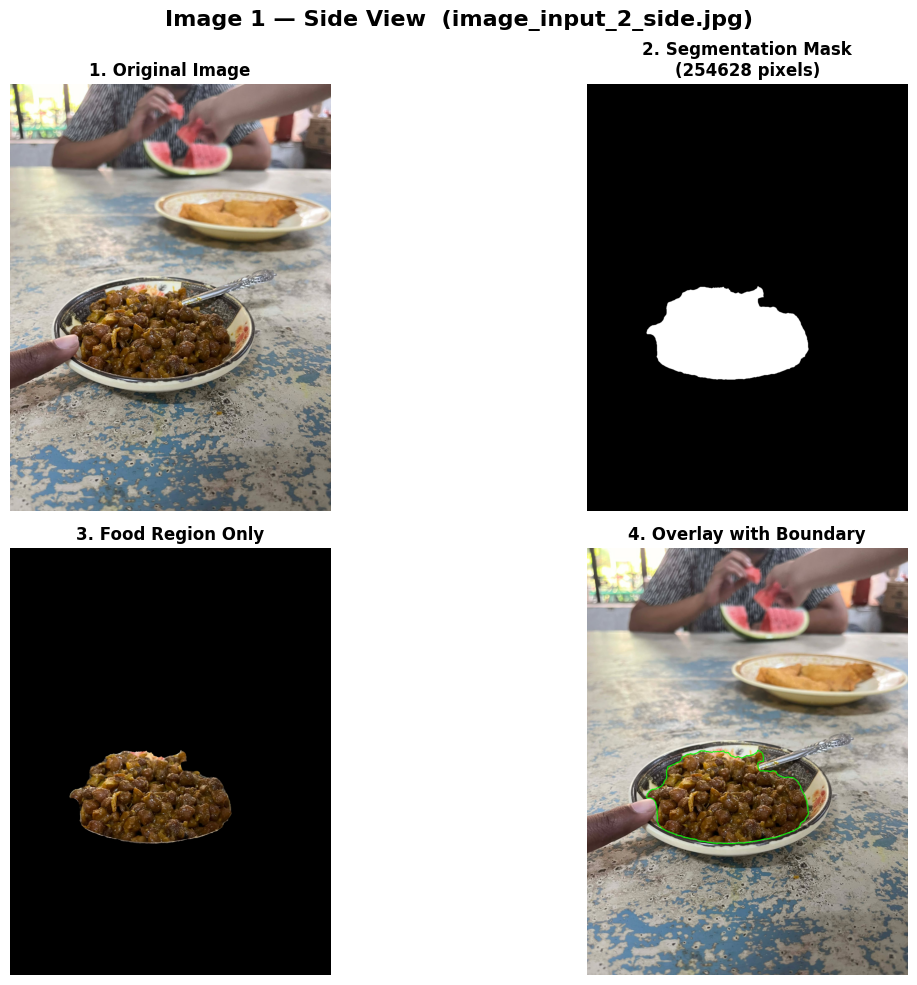

✅ Image 1 visualization complete!

Overlay — image 2 (top view):


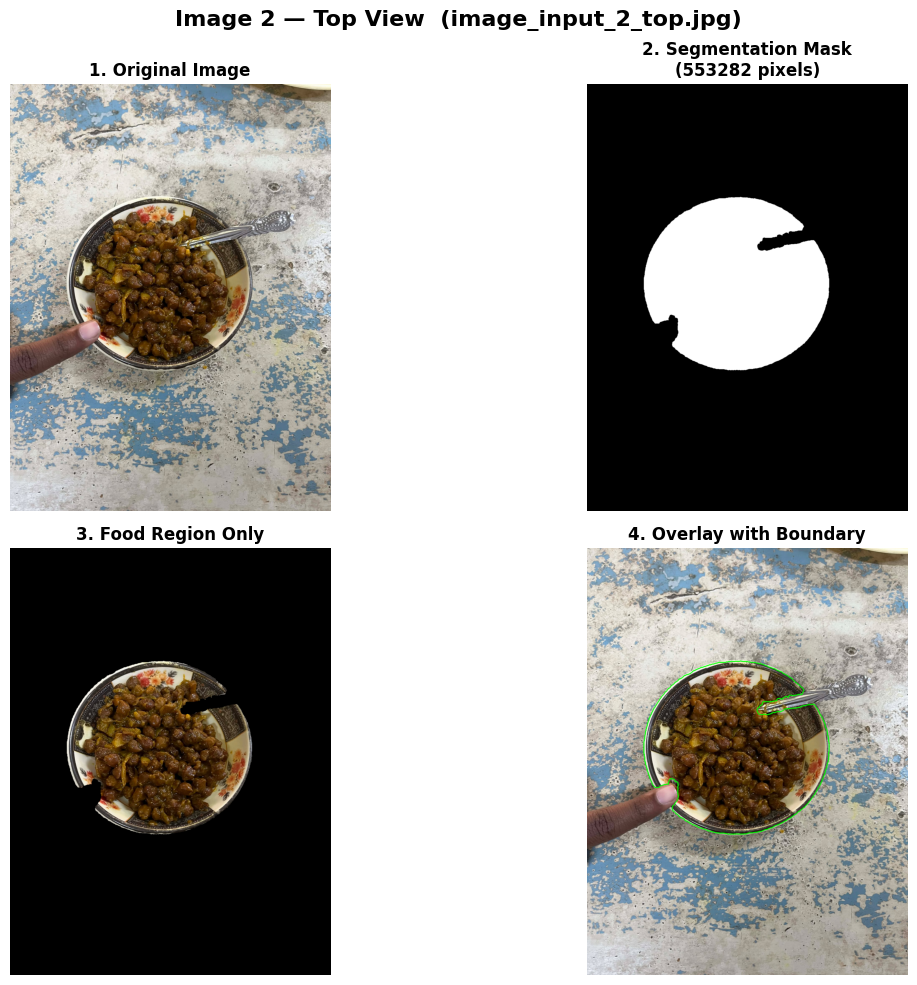

✅ Image 2 visualization complete!


In [29]:
def visualize_mask_on_image(image: np.ndarray, mask: np.ndarray, title: str = 'Segmentation Visualization') -> None:
    """
    Display image with segmentation mask overlay and statistics.

    Args:
        image: RGB image (3-channel)
        mask: Binary segmentation mask
        title: Figure title
    """
    if image is None or mask is None:
        print("❌ Image or mask is None!")
        return

    # Ensure mask is uint8 binary for OpenCV operations
    mask = (mask > 0).astype(np.uint8) * 255

    # Align mask size with image size if needed
    h, w = image.shape[:2]
    if mask.shape != (h, w):
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Panel 1: Original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title("1. Original Image", fontweight='bold')
    axes[0, 0].axis('off')

    # Panel 2: Mask only
    axes[0, 1].imshow(mask, cmap='gray')
    axes[0, 1].set_title(f"2. Segmentation Mask\n({np.count_nonzero(mask)} pixels)", fontweight='bold')
    axes[0, 1].axis('off')

    # Panel 3: Food region only
    masked_rgb = cv2.bitwise_and(image, image, mask=mask)
    axes[1, 0].imshow(masked_rgb)
    axes[1, 0].set_title("3. Food Region Only", fontweight='bold')
    axes[1, 0].axis('off')

    # Panel 4: Overlay with boundary
    overlay = image.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (0, 255, 0), 3)
    axes[1, 1].imshow(overlay)
    axes[1, 1].set_title("4. Overlay with Boundary", fontweight='bold')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()


print("\n" + "="*60)
print("STEP 4: VISUALIZE SEGMENTATION")
print("="*60)

# ── Image 1 ────────────────────────────────────────────────────────────
print("\nOverlay — image 1 (side view):")
mask1_to_show = None
if 'segments1' in globals() and isinstance(segments1, list) and len(segments1) > 0:
    seg = segments1[0]
    if isinstance(seg, dict) and 'mask' in seg:
        mask1_to_show = seg['mask']
elif 'mask1' in globals():
    mask1_to_show = mask1

img1_to_show = image1 if 'image1' in globals() and image1 is not None else None

if img1_to_show is not None and mask1_to_show is not None:
    visualize_mask_on_image(img1_to_show, mask1_to_show,
                            title=f'Image 1 — Side View  ({IMAGE1_FILENAME})')
    print("✅ Image 1 visualization complete!")
else:
    print("⚠️  Cannot visualize image 1: missing image or mask")

# ── Image 2 ────────────────────────────────────────────────────────────
print("\nOverlay — image 2 (top view):")
mask2_to_show = None
if 'segments2' in globals() and isinstance(segments2, list) and len(segments2) > 0:
    seg = segments2[0]
    if isinstance(seg, dict) and 'mask' in seg:
        mask2_to_show = seg['mask']
elif 'mask2' in globals():
    mask2_to_show = mask2

img2_to_show = image2 if 'image2' in globals() and image2 is not None else None

if img2_to_show is not None and mask2_to_show is not None:
    visualize_mask_on_image(img2_to_show, mask2_to_show,
                            title=f'Image 2 — Top View  ({IMAGE2_FILENAME})')
    print("✅ Image 2 visualization complete!")
else:
    print("⚠️  Cannot visualize image 2: missing image or mask")
    print("   Tip: run the main workflow cell first.")


## 2.5 Step 5: Voxel-Grid Volume Estimation (Two-View Pipeline)

Full pipeline: **Preprocessing → 3D Reconstruction → Point Cloud → Voxel Grid → Volume**

Inputs required:
- Two images of the same food from different angles (`image1`, `image2`)
- Two corresponding segmentation masks (`mask1`, `mask2`)
- `pixel_length_mm`: real-world size of one pixel in mm (from Module 3 calibration)
- `food_type` (optional): used to apply shape-aware corrections

The pipeline follows these stages:
1. **Preprocess masks** — morphological cleaning, hole filling, keep largest region
2. **Scale pixels → real-world** — using per-pixel length from calibration
3. **Feature matching** — SIFT/ORB to find correspondences between the two views
4. **Triangulate** → sparse 3D point cloud
5. **Clean point cloud** — outlier removal
6. **Voxelize** — fill 3D grid with occupied voxels
7. **Count voxels** → compute volume


**helpers for Many segmentation in one image**

In [30]:
def load_image_file(path: str) -> np.ndarray:
    """Load an image from disk and convert BGR → RGB."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
 
 
def load_yolo_coordinates(label_path: str) -> list[dict]:
    """
    Parse a YOLO label file that may contain multiple detections.
 
    Each line format (segmentation):
        <class_id> x1 y1 x2 y2 ... xn yn   (normalised 0–1)
 
    Returns a list of dicts, one per detection:
        {
            'class_id'         : str,
            'normalized_coords': [(x, y), ...],
        }
    """
    detections = []
    if not os.path.exists(label_path):
        print(f"⚠️  Label file not found: {label_path}")
        return detections
 
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            class_id = parts[0]
            coords_flat = list(map(float, parts[1:]))
            # pair up into (x, y) tuples
            coords = [
                (coords_flat[i], coords_flat[i + 1])
                for i in range(0, len(coords_flat) - 1, 2)
            ]
            detections.append({
                "class_id"         : class_id,
                "normalized_coords": coords,
            })
 
    return detections
 
 
def coordinates_to_mask(
    img_height: int,
    img_width: int,
    normalized_coords: list[tuple[float, float]],
) -> np.ndarray:
    """
    Convert normalised YOLO polygon coordinates → binary mask (uint8, 0/255).
    """
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    if not normalized_coords:
        return mask
 
    pixel_coords = np.array(
        [[x * img_width, y * img_height] for x, y in normalized_coords],
        dtype=np.int32,
    )
    cv2.fillPoly(mask, [pixel_coords], 255)
    return mask

# **Preprocessing**

In [31]:
def preprocess_mask(mask: np.ndarray) -> np.ndarray:
    """
    Clean a raw segmentation mask:
      1. Binarise (Otsu threshold)
      2. Morphological closing  – fills small gaps
      3. Hole filling           – closes interior holes
      4. Keep largest region    – removes stray blobs
 
    Args:
        mask: Raw segmentation mask (uint8, any range)
 
    Returns:
        Cleaned binary mask (uint8, values 0 or 255)
    """
    # 1. Binarise
    _, binary = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
 
    # 2. Morphological closing (fills small gaps / broken edges)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
 
    # 3. Flood-fill holes from the border
    h, w   = closed.shape
    flood  = closed.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)
    holes_filled = closed | cv2.bitwise_not(flood)
 
    # 4. Keep only significant connected components (removes thumb/noise).
    #    A blob is kept only if its area >= 5% of the largest component.
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        holes_filled, connectivity=8
    )
    if num_labels <= 1:
        return holes_filled
    component_areas = stats[1:, cv2.CC_STAT_AREA]  # skip background label 0
    max_area = component_areas.max()
    min_area = max(max_area * 0.05, 100)           # at least 5% of main blob
    clean = np.zeros_like(holes_filled)
    for lbl_idx, area in enumerate(component_areas, start=1):
        if area >= min_area:
            clean[labels == lbl_idx] = 255
 
    return clean

#  3-D point cloud from two views

In [32]:
def build_point_cloud_two_views(
    img1: np.ndarray,
    img2: np.ndarray,
    mask1: np.ndarray,
    mask2: np.ndarray,
    pixel_length_mm: float,
    max_points: int = 5000,
) -> np.ndarray:
    """
    Estimate a 3-D point cloud from two views using SIFT feature matching
    + stereo triangulation.  Falls back to a single-view flat-plane estimate
    when fewer than 8 good matches are found.
 
    Returns (N, 3) float32 array in mm.
    """
    gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    h, w  = gray1.shape
 
    # 1. SIFT keypoints inside the food mask
    try:
        sift = cv2.SIFT_create(nfeatures=2000)
    except AttributeError:
        sift = cv2.xfeatures2d.SIFT_create(nfeatures=2000)
 
    kp1, des1 = sift.detectAndCompute(gray1, mask1)
    kp2, des2 = sift.detectAndCompute(gray2, mask2)
 
    # 2. FLANN + Lowe ratio matching
    MIN_GOOD = 8
    if (
        des1 is not None and des2 is not None
        and len(kp1) >= MIN_GOOD
        and len(kp2) >= MIN_GOOD
    ):
        index_params  = dict(algorithm=1, trees=5)
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)
        raw   = flann.knnMatch(des1, des2, k=2)
        good  = [m for m, n in raw if m.distance < 0.75 * n.distance]
    else:
        good = []
 
    # 3 + 4. Pose estimation + triangulation (or fallback)
    if len(good) >= MIN_GOOD:
        pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
        pts2 = np.float32([kp2[m.trainIdx].pt for m in good])
 
        focal = float(max(h, w))
        cx, cy = w / 2.0, h / 2.0
        K = np.array([[focal, 0, cx],
                      [0, focal, cy],
                      [0,     0,  1]], dtype=np.float64)
 
        E, inlier_mask = cv2.findEssentialMat(
            pts1, pts2, K, method=cv2.RANSAC, prob=0.999, threshold=1.0
        )
        _, R, t, pose_mask = cv2.recoverPose(E, pts1, pts2, K, mask=inlier_mask)
 
        inlier_pts1 = pts1[pose_mask.ravel() > 0]
        inlier_pts2 = pts2[pose_mask.ravel() > 0]
 
        P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])
        P2 = K @ np.hstack([R, t])
 
        pts4d = cv2.triangulatePoints(P1, P2, inlier_pts1.T, inlier_pts2.T)
        pts3d = (pts4d[:3] / pts4d[3]).T
 
        valid = pts3d[:, 2] > 0
        pts3d       = pts3d[valid]
        inlier_pts1 = inlier_pts1[valid]
 
        xi = np.clip(inlier_pts1[:, 0].astype(int), 0, w - 1)
        yi = np.clip(inlier_pts1[:, 1].astype(int), 0, h - 1)
        in_mask = mask1[yi, xi] > 0
        pts3d = pts3d[in_mask]
 
        print(f"   ✅ Triangulated {len(pts3d):,} pts from {len(good)} matches")
 
    else:
        print(f"   ⚠️  Only {len(good)} matches — single-view fallback")
        ys, xs = np.where(mask1 > 0)
        if len(xs) == 0:
            return np.zeros((0, 3), dtype=np.float32)
        depth_estimate = (ys.max() - ys.min()) * 0.3
        depths = np.full(len(xs), depth_estimate, dtype=np.float32)
        pts3d  = np.column_stack([xs.astype(np.float32),
                                   ys.astype(np.float32),
                                   depths])
 
    # 5. Scale pixels → mm, subsample
    pts3d_mm = pts3d.astype(np.float32) * pixel_length_mm
    if len(pts3d_mm) > max_points:
        idx      = np.random.choice(len(pts3d_mm), max_points, replace=False)
        pts3d_mm = pts3d_mm[idx]
 
    return pts3d_mm

# Statistical outlier removal

In [33]:
def remove_outliers(
    points: np.ndarray,
    k: int = 20,
    std_ratio: float = 2.0,
) -> np.ndarray:
    """
    Remove statistical outliers from a point cloud using k-NN mean distance.
    Points beyond  mean + std_ratio * std  are discarded.
    """
    if len(points) < k + 1:
        return points
 
    diff  = points[:, None, :] - points[None, :, :]
    dists = np.sqrt((diff ** 2).sum(axis=-1))
    dists.sort(axis=1)
 
    mean_k_dist = dists[:, 1:k + 1].mean(axis=1)
    threshold   = mean_k_dist.mean() + std_ratio * mean_k_dist.std()
    mask        = mean_k_dist <= threshold
 
    print(f"   Outlier removal: {points.shape[0]} → {mask.sum()} pts kept")
    return points[mask]

# Voxelisation

In [34]:
def voxelize_point_cloud(
    points_mm: np.ndarray,
    voxel_size_mm: float,
) -> int:
    """
    Count occupied voxels in a uniform voxel grid.
    Each point is mapped to floor(coord / voxel_size); duplicates collapse.
    """
    if len(points_mm) == 0:
        return 0
 
    shifted = points_mm - points_mm.min(axis=0)
    indices = np.floor(shifted / voxel_size_mm).astype(np.int32)
    occupied = {(ix, iy, iz) for ix, iy, iz in indices}
    return len(occupied)
 
 
# ============================================================
# STEP 5 — STAGE 5: Shape correction factors
# ============================================================
 
SHAPE_CORRECTION = {
    "rice"     : 1.00,
    "soup"     : 1.00,
    "salad"    : 1.00,
    "apple"    : 0.52,
    "orange"   : 0.52,
    "egg"      : 0.50,
    "meatball" : 0.52,
    "pizza"    : 0.25,
    "flatbread": 0.20,
    "naan"     : 0.20,
    "burger"   : 0.65,
    "sandwich" : 0.60,
    "cake"     : 0.70,
    "default"  : 1.00,
}
 
def get_shape_correction(food_type: str) -> float:
    ft = food_type.lower() if food_type else ""
    for keyword, factor in SHAPE_CORRECTION.items():
        if keyword in ft:
            return factor
    return SHAPE_CORRECTION["default"]

# TOP-LEVEL single-item function for Voxel

In [35]:
def calculate_volume_voxel(
    img1: np.ndarray,
    img2: np.ndarray,
    mask1: np.ndarray,
    mask2: np.ndarray,
    pixel_length_mm: float,
    food_type: str = "",
    voxel_size_mm: float = 5.0,
) -> dict:
    """
    Full voxel-grid volume estimation pipeline for ONE food item.
 
    Args:
        img1, img2        : Two RGB views (H×W×3 uint8)
        mask1, mask2      : Segmentation masks for this item in each view (H×W uint8)
        pixel_length_mm   : Real-world size of one pixel [mm]
        food_type         : Food class name (for shape correction)
        voxel_size_mm     : Voxel side length [mm]
 
    Returns:
        dict with volume_mm3, volume_cm3, volume_ml, volume_l, and diagnostics
    """
    print("\n" + "=" * 60)
    print(f"VOXEL-GRID VOLUME ESTIMATION  [{food_type or 'unknown'}]")
    print("=" * 60)
 
    # 1. Preprocess
    print("\n[1/5] Preprocessing masks...")
    clean1 = preprocess_mask(mask1)
    clean2 = preprocess_mask(mask2)
    pixel_count = int(np.count_nonzero(clean1))
    print(f"   Mask1 food pixels: {pixel_count:,}")
    print(f"   Mask2 food pixels: {np.count_nonzero(clean2):,}")
 
    # 2. Build point cloud
    print("\n[2/5] Building 3-D point cloud...")
    points_mm = build_point_cloud_two_views(
        img1, img2, clean1, clean2, pixel_length_mm
    )
    print(f"   Raw cloud: {len(points_mm):,} points")
 
    if len(points_mm) == 0:
        print("❌ Empty point cloud — check inputs")
        return {}
 
    # 3. Outlier removal
    print("\n[3/5] Removing outliers...")
    points_mm = remove_outliers(points_mm)
 
    # 4. Voxelise
    print(f"\n[4/5] Voxelising (voxel size = {voxel_size_mm} mm)...")
    num_voxels = voxelize_point_cloud(points_mm, voxel_size_mm)
    print(f"   Occupied voxels: {num_voxels:,}")
 
    # 5. Volume
    print("\n[5/5] Computing volume...")
    shape_factor = get_shape_correction(food_type)
    raw_vol_mm3  = num_voxels * (voxel_size_mm ** 3)
    volume_mm3   = raw_vol_mm3 * shape_factor
 
    result = {
        "pixel_count"     : pixel_count,
        "num_points"      : len(points_mm),
        "num_voxels"      : num_voxels,
        "voxel_size_mm"   : voxel_size_mm,
        "shape_correction": shape_factor,
        "volume_mm3"      : volume_mm3,
        "volume_cm3"      : volume_mm3 / 1_000,
        "volume_ml"       : volume_mm3 / 1_000,
        "volume_l"        : volume_mm3 / 1_000_000,
        "food_type"       : food_type or "unknown",
    }
 
    print(f"\n{'=' * 60}")
    print(f"  Food type        : {result['food_type']}")
    print(f"  Pixel count      : {result['pixel_count']:,}")
    print(f"  Point cloud size : {result['num_points']:,}")
    print(f"  Occupied voxels  : {result['num_voxels']:,}")
    print(f"  Voxel size       : {result['voxel_size_mm']} mm")
    print(f"  Shape correction : {result['shape_correction']}")
    print(f"  Volume           : {result['volume_mm3']:,.2f} mm³")
    print(f"                   : {result['volume_cm3']:,.4f} cm³  /  {result['volume_ml']:,.4f} mL")
    print("=" * 60)
 
    return result

# Helper for Many Item Voxelation

In [36]:
def _bbox_from_mask(mask: np.ndarray) -> tuple[int, int, int, int]:
    """
    Compute the bounding box of the non-zero region of a mask.
    Returns (x, y, w, h) in pixels.
    """
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return (0, 0, 0, 0)
    x, y = int(xs.min()), int(ys.min())
    w, h = int(xs.max()) - x, int(ys.max()) - y
    return (x, y, w, h)
 
 
def _bbox_center(bbox: tuple[int, int, int, int]) -> np.ndarray:
    """Return the (cx, cy) centre of a bbox tuple (x, y, w, h)."""
    x, y, w, h = bbox
    return np.array([x + w / 2.0, y + h / 2.0])
 
 
def match_by_position(
    segs1: list[dict],
    segs2: list[dict],
) -> list[tuple[dict, dict]]:
    """
    Strategy B — pair each segment in segs1 with the spatially nearest
    segment in segs2 using the Hungarian algorithm (optimal assignment).
 
    Each segment dict must contain a 'bbox' key: (x, y, w, h).
 
    Returns:
        List of (seg_from_img1, seg_from_img2) pairs.
    """
    if not segs1 or not segs2:
        return []
 
    # Build cost matrix: Euclidean distance between bbox centres
    cost = np.array([
        [np.linalg.norm(_bbox_center(s1["bbox"]) - _bbox_center(s2["bbox"]))
         for s2 in segs2]
        for s1 in segs1
    ])
 
    row_idx, col_idx = linear_sum_assignment(cost)
    return [(segs1[r], segs2[c]) for r, c in zip(row_idx, col_idx)]
 
 

# Parse a single YOLO label file into segment dicts

In [37]:
def parse_yolo_segments(
    image: np.ndarray,
    all_coords: list[dict],
) -> list[dict]:
    """
    Convert the output of load_yolo_coordinates() into a list of segment
    dicts that carry the mask AND its bounding box (needed by Strategy B).
 
    Each output dict:
        {
            'class_id': str,
            'mask'    : np.ndarray  (H×W uint8),
            'bbox'    : (x, y, w, h) in pixels,
        }
    """
    h, w   = image.shape[:2]
    result = []
    for coords in all_coords:
        mask = coordinates_to_mask(h, w, coords["normalized_coords"])
        bbox = _bbox_from_mask(mask)
        result.append({
            "class_id": coords["class_id"],
            "mask"    : mask,
            "bbox"    : bbox,
        })
    return result

# Calculate all item

In [38]:
def calculate_volume_all_items(
    img1: np.ndarray,
    img2: np.ndarray,
    segments1: list[dict],
    segments2: list[dict],
    pixel_length_mm: float,
    voxel_size_mm: float = 5.0,
) -> dict[str, dict]:
    """
    Run the full voxel-grid volume pipeline for ALL food items in both images.
 
    Matching strategy
    -----------------
    • Items with different class_ids are paired directly by class.
    • Items sharing the same class_id (duplicates, e.g. two apples) are
      paired by bounding-box centre distance — Strategy B (Hungarian algorithm).
 
    Args:
        img1, img2        : Full RGB views (H×W×3 uint8)
        segments1         : Output of parse_yolo_segments() for image 1
        segments2         : Output of parse_yolo_segments() for image 2
        pixel_length_mm   : Real-world pixel size [mm]
        voxel_size_mm     : Voxel side length [mm]
 
    Returns:
        dict mapping  food_label → result_dict
        (food_label is  "class_id"  or  "class_id_0", "class_id_1"  for duplicates)
    """
    print("\n" + "=" * 60)
    print("MULTI-ITEM VOLUME ESTIMATION  (Strategy B active)")
    print("=" * 60)
    print(f"  Segments in image 1 : {len(segments1)}")
    print(f"  Segments in image 2 : {len(segments2)}")
 
    # ── Group segments by class_id ───────────────────────────────────────────
    def group_by_class(segs: list[dict]) -> dict[str, list[dict]]:
        groups: dict[str, list[dict]] = {}
        for s in segs:
            groups.setdefault(s["class_id"], []).append(s)
        return groups
 
    groups1 = group_by_class(segments1)
    groups2 = group_by_class(segments2)
 
    all_results: dict[str, dict] = {}
 
    for class_id, segs1 in groups1.items():
 
        if class_id not in groups2:
            print(f"\n⚠️  '{class_id}' found in image 1 but NOT image 2 — skipping")
            continue
 
        segs2 = groups2[class_id]
 
        # ── Strategy B: match same-class items by spatial position ───────────
        pairs = match_by_position(segs1, segs2)
 
        for i, (s1, s2) in enumerate(pairs):
            # Use "class_id" for single items, "class_id_0/1/..." for duplicates
            label = f"{class_id}_{i}" if len(pairs) > 1 else class_id
 
            print(f"\n▶  Processing item: {label}")
 
            result = calculate_volume_voxel(
                img1            = img1,
                img2            = img2,
                mask1           = s1["mask"],
                mask2           = s2["mask"],
                pixel_length_mm = pixel_length_mm,
                food_type       = class_id,
                voxel_size_mm   = voxel_size_mm,
            )
            all_results[label] = result
 
    # ── Summary table ────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("SUMMARY — all items")
    print("=" * 60)
    print(f"  {'Item':<20} {'Volume (mL)':>12}")
    print(f"  {'-'*20} {'-'*12}")
    for label, r in all_results.items():
        if r:
            print(f"  {label:<20} {r['volume_ml']:>12.2f}")
    print("=" * 60)
 
    return all_results

# main_Work

Loading images...

Parsing masks for image 1...
✅ Loaded mask: /media/rageeb-hasan-shafee/New Volume/Capstone Project/masks/input_2_side_mask_001_seg_004_from_txt.npy
   Shape: (1280, 960), Food pixels: 99,246
   [beguni] bbox=(285, 970, 774, 447), food_pixels=254,628

✅ parse_npy_segments: 1 item(s) ready

Parsing masks for image 2...
✅ Loaded mask: /media/rageeb-hasan-shafee/New Volume/Capstone Project/masks/input_2_top_mask_001.npy
   Shape: (1280, 960), Food pixels: 215,314
   [beguni] bbox=(272, 541, 886, 831), food_pixels=553,282

✅ parse_npy_segments: 1 item(s) ready

Image 1: 1 segment(s) ready

Image 2: 1 segment(s) ready

Overlay — image 1, first segment:


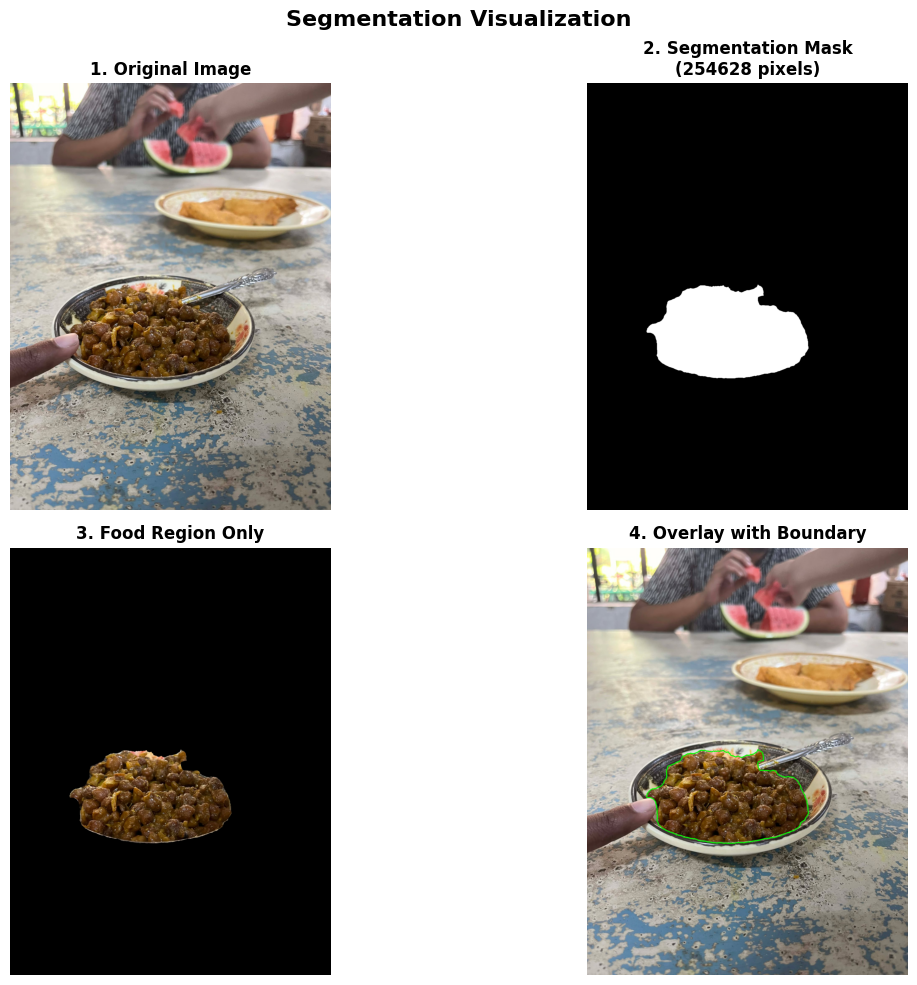


MULTI-ITEM VOLUME ESTIMATION  (Strategy B active)
  Segments in image 1 : 1
  Segments in image 2 : 1

▶  Processing item: beguni

VOXEL-GRID VOLUME ESTIMATION  [beguni]

[1/5] Preprocessing masks...
   Mask1 food pixels: 254,628
   Mask2 food pixels: 553,282

[2/5] Building 3-D point cloud...
   ✅ Triangulated 2 pts from 9 matches
   Raw cloud: 2 points

[3/5] Removing outliers...

[4/5] Voxelising (voxel size = 5.0 mm)...
   Occupied voxels: 1

[5/5] Computing volume...

  Food type        : beguni
  Pixel count      : 254,628
  Point cloud size : 2
  Occupied voxels  : 1
  Voxel size       : 5.0 mm
  Shape correction : 1.0
  Volume           : 125.00 mm³
                   : 0.1250 cm³  /  0.1250 mL

SUMMARY — all items
  Item                  Volume (mL)
  -------------------- ------------
  beguni                       0.12

FINAL RESULTS

  beguni:
    Volume  : 0.12 mL  (0.1250 cm³)
    Voxels  : 1
    Points  : 2
    Correction factor: 1.0


In [39]:
# ======================================================================
# MAIN WORKFLOW — NPY mask input
# ======================================================================
# Adjust the filenames below, then run this cell.
# Uses IMAGES_DIR and MASKS_DIR from the configuration cell above.
# ======================================================================
# ── File names only (directories come from config cell) ──────────────────
IMAGE2_FILENAME = "image_input_2_top.jpg"
IMAGE1_FILENAME = "image_input_2_side.jpg"

# List of .npy mask files for each view.
# One .npy per food item — add more entries for multiple items in one image.
MASKS2_FILENAMES = [
    "input_2_top_mask_001.npy",   # first food item in view 1
    # "input_1_top_mask_001.npy", # second food item (uncomment if needed)
    # "input_1_top_mask_002.npy", # third food item (uncomment if needed)

]
MASKS1_FILENAMES = [
    "input_2_side_mask_001_seg_004_from_txt.npy",   # matching food item in view 2
    # "input_1_side_mask_001.npy",
    # "input_1_side_mask_002.npy",
    # "input_1_side_mask_003.npy",
]

# Optional: supply a class_id label per mask (same order as MASKS*_FILENAMES).
# If None, labels are auto-assigned '0', '1', ...
CLASS_IDS = ["beguni", "beguni", "beguni"]  # one label per mask in MASKS1_FILENAMES; view 2 extras get last label

# ── Calibration (from Module 3) ───────────────────────────────────────────
PIXEL_LENGTH_MM = 0.5    # mm per pixel
VOXEL_SIZE_MM   = 5.0    # voxel side length in mm

# ── Load images ──────────────────────────────────────────────────────────
print("Loading images...")
image1 = load_image_file(os.path.join(IMAGES_DIR, IMAGE1_FILENAME))
image2 = load_image_file(os.path.join(IMAGES_DIR, IMAGE2_FILENAME))

# ── Parse NPY masks → segment dicts ─────────────────────────────────────
print("\nParsing masks for image 1...")
segments1 = parse_npy_segments(
    image     = image1,
    npy_paths = [os.path.join(MASKS_DIR, f) for f in MASKS1_FILENAMES],
    class_ids = CLASS_IDS,
)

print("\nParsing masks for image 2...")
segments2 = parse_npy_segments(
    image     = image2,
    npy_paths = [os.path.join(MASKS_DIR, f) for f in MASKS2_FILENAMES],
    class_ids = CLASS_IDS,
)

print(f"\nImage 1: {len(segments1)} segment(s) ready")
print(f"\nImage 2: {len(segments2)} segment(s) ready")

# ── (Optional) Visualise masks before estimation ─────────────────────────
if segments1:
    print("\nOverlay — image 1, first segment:")
    visualize_mask_on_image(image1, segments1[0]['mask'])

# ── Run multi-item volume estimation ─────────────────────────────────────
all_results = calculate_volume_all_items(
    img1            = image1,
    img2            = image2,
    segments1       = segments1,
    segments2       = segments2,
    pixel_length_mm = PIXEL_LENGTH_MM,
    voxel_size_mm   = VOXEL_SIZE_MM,
)

# ── Print results ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
for food_label, result in all_results.items():
    if result:
        print(f"\n  {food_label}:")
        print(f"    Volume  : {result['volume_ml']:.2f} mL  ({result['volume_cm3']:.4f} cm³)")
        print(f"    Voxels  : {result['num_voxels']}")
        print(f"    Points  : {result['num_points']}")
        print(f"    Correction factor: {result['shape_correction']}")


## 3. Advanced: Reusable Integration Class (Optional)

For production use, integrate with other modules using the VolumeEstimator class.

In [40]:
# def visualize_segmentation_with_volume(mask: np.ndarray, 
#                                        estimated_volume: float, 
#                                        image: np.ndarray = None,
#                                        title: str = "Volume Estimation Result") -> None:
#     """
#     Visualize the segmentation mask with volume information.
#     If original image is provided, shows comparison view.
    
#     Parameters:
#     -----------
#     mask : np.ndarray
#         Binary segmentation mask
#     estimated_volume : float
#         Estimated volume in mm³
#     image : np.ndarray, optional
#         Original food image (RGB format) for comparison
#     title : str
#         Title for the visualization
#     """
    
#     if image is not None:
#         # Show 4-panel view with image
#         fig, axes = plt.subplots(2, 2, figsize=(14, 10))
#         fig.suptitle(title, fontsize=16, fontweight='bold')
        
#         # 1. Original Image
#         axes[0, 0].imshow(image)
#         axes[0, 0].set_title('Original Image')
#         axes[0, 0].axis('off')
        
#         # 2. Segmentation Mask
#         axes[0, 1].imshow(mask, cmap='gray')
#         axes[0, 1].set_title('Segmentation Mask (All Food Items)')
#         axes[0, 1].axis('off')
        
#         # 3. Masked Image (showing only segmented region)
#         masked_image = image.copy()
#         for c in range(3):
#             masked_image[:, :, c] = image[:, :, c] * (mask > 0).astype(np.uint8)
#         axes[1, 0].imshow(masked_image)
#         axes[1, 0].set_title('Segmented Regions')
#         axes[1, 0].axis('off')
        
#         # 4. Overlay with contours and volume information
#         overlay_image = image.copy()
#         contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         cv2.drawContours(overlay_image, contours, -1, (0, 255, 0), 2)
        
#         # Add volume information text
#         volume_text = f"Total Volume: {estimated_volume:.2f} mm³"
#         volume_ml_text = f"({estimated_volume/1000:.4f} mL)"
        
#         cv2.putText(overlay_image, volume_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 
#                     1.0, (0, 0, 255), 2)
#         cv2.putText(overlay_image, volume_ml_text, (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 
#                     0.8, (0, 0, 255), 2)
        
#         axes[1, 1].imshow(overlay_image)
#         axes[1, 1].set_title('Volume Information Overlay')
#         axes[1, 1].axis('off')
#     else:
#         # Show 2-panel view with only mask
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#         fig.suptitle(title, fontsize=16, fontweight='bold')
        
#         # 1. Segmentation Mask
#         axes[0].imshow(mask, cmap='gray')
#         axes[0].set_title('Segmentation Mask (All Food Items)')
#         axes[0].axis('off')
        
#         # 2. Mask with volume text
#         mask_display = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
#         contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         cv2.drawContours(mask_display, contours, -1, (0, 255, 0), 2)
        
#         volume_text = f"Total Volume: {estimated_volume:.2f} mm³ ({estimated_volume/1000:.4f} mL)"
#         cv2.putText(mask_display, volume_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 
#                     0.8, (0, 0, 255), 2)
        
#         axes[1].imshow(mask_display)
#         axes[1].set_title('Volume Information')
#         axes[1].axis('off')
    
#     plt.tight_layout()
#     plt.show()

# # Visualize the results
# if original_image is not None:
#     print("\n✓ Showing visualization with original image...")
#     visualize_segmentation_with_volume(segmentation_mask, estimated_volume_mm3, original_image)
# else:
#     print("\n✓ Showing visualization with mask only...")
#     visualize_segmentation_with_volume(segmentation_mask, estimated_volume_mm3)

## Integration Guide: Using Module 4 with Other Modules

### Data Flow:
```
Module 1 (Segmentation - SAM)  --[segmentation_mask]--> 
Module 4 (Volume Estimation) <--[volume_per_pixel]-- Module 3 (Thumb Calibration)
                                  |
                                  v
                          [estimated_volume]
                                  |
                                  v
           Final Integration (Combine all modules)
```

### Input Requirements for Module 4:
1. **Segmentation Mask** (from Module 1 - SAM Food Model)
   - Binary mask (0 for background, 255 or non-zero for food item)
   - Format: NumPy array or image file (PNG, JPG)
   - Size: Should match the original image dimensions

2. **Volume Per Pixel** (from Module 3 - Thumb Detection & Calibration)
   - Calibration value in mm³/pixel
   - Scalar float value
   - Example: 2.5 mm³/pixel

### Output from Module 4:
- **Volume Estimation Results**
  - Total volume in multiple units (mm³, cm³, mL, L)
  - Pixel count in segmented region
  - Visualization overlay with volume information

### How to Use:
```python
# Step 1: Get inputs from other modules
segmentation_mask = load_mask_from_module_1("path/to/mask.png")
volume_per_pixel = load_calibration_from_module_3()

# Step 2: Create estimator
estimator = VolumeEstimator(volume_per_pixel=volume_per_pixel)

# Step 3: Estimate volume
result = estimator.estimate_volume_single(segmentation_mask)

# Step 4: Use the result
print(f"Estimated volume: {result['volume_ml']} mL")
```

### Key Functions for Integration:
- `calculate_pixel_count(mask)` - Count pixels in segmented region
- `estimate_volume(pixel_count, volume_per_pixel)` - Calculate volume
- `VolumeEstimator` - Main class for reusable volume estimation
- `visualize_segmentation_with_volume()` - Visualize results

## Kaggle Usage Examples

### Example 1: Load from Kaggle Dataset
```python
# Load mask and image from Kaggle input
mask = load_mask_from_kaggle("mask_sample_01.png")
image = load_image_from_kaggle("image_sample_01.jpg")

# Estimate volume
estimator = VolumeEstimator(volume_per_pixel=2.5)
result = estimator.estimate_volume_single(mask, image)

# Save results to Kaggle output
save_results_to_json(result)
```

### Example 2: Batch Processing Multiple Images
```python
# Get list of all masks in Kaggle input
list_files_in_kaggle_input("segmentation_masks")

# Process all masks
all_masks = []
for i in range(1, 11):  # Process 10 images
    mask_file = f"mask_{i:02d}.png"
    try:
        mask = load_mask_from_kaggle(mask_file)
        all_masks.append(mask)
    except FileNotFoundError:
        break

# Batch estimate volumes
results = estimator.estimate_volume_batch(all_masks)

# Save summary
summary = estimator.get_summary_statistics()
save_results_to_json(summary, "volume_summary.json")
```

### Example 3: Use with Module 3 Calibration (Coming from Another Notebook)
```python
# Load calibration value that was computed in Module 3
# Either hardcode or load from file
calibration_value = 2.5  # mm³/pixel from Module 3

# Initialize with calibration
estimator = VolumeEstimator(volume_per_pixel=calibration_value)

# Process your images
mask = load_mask_from_kaggle("food_mask.png")
result = estimator.estimate_volume_single(mask)
```

In [41]:
# # ============================================================
# # ADVANCED FEATURES FOR PRODUCTION USE
# # ============================================================

# def save_results_to_json(results: Dict[str, Any], output_filename: str = "volume_estimation_results.json") -> None:
#     """
#     Save volume estimation results to JSON file for later analysis or integration.
#     Works with both Kaggle and local directories.
    
#     Parameters:
#     -----------
#     results : dict
#         Results dictionary from estimate_volume_single()
#     output_filename : str
#         Filename to save the JSON file
#     """
#     import json
    
#     # Save to output directory
#     output_path = os.path.join(BASE_OUTPUT_DIR, output_filename)
    
#     with open(output_path, 'w') as f:
#         json.dump(results, f, indent=4)
#     print(f"✓ Results saved to {output_path}")

# def load_mask_from_kaggle(mask_filename: str) -> np.ndarray:
#     """
#     Load a segmentation mask from Kaggle input directory.
    
#     Parameters:
#     -----------
#     mask_filename : str
#         Filename of the mask (looks in SEGMENTATION_MASKS_DIR)
    
#     Returns:
#     --------
#     np.ndarray
#         Binary segmentation mask
#     """
#     mask_path = os.path.join(SEGMENTATION_MASKS_DIR, mask_filename)
    
#     if not os.path.exists(mask_path):
#         raise FileNotFoundError(f"Mask file not found at: {mask_path}")
    
#     mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#     print(f"✓ Loaded mask from: {mask_path}")
#     return mask

# def load_image_from_kaggle(image_filename: str) -> np.ndarray:
#     """
#     Load an image from Kaggle input directory.
    
#     Parameters:
#     -----------
#     image_filename : str
#         Filename of the image (looks in ORIGINAL_IMAGES_DIR)
    
#     Returns:
#     --------
#     np.ndarray
#         Image in RGB format
#     """
#     image_path = os.path.join(ORIGINAL_IMAGES_DIR, image_filename)
    
#     if not os.path.exists(image_path):
#         raise FileNotFoundError(f"Image file not found at: {image_path}")
    
#     image = cv2.imread(image_path)
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     print(f"✓ Loaded image from: {image_path}")
#     return image

# def load_mask_from_file(mask_path: str) -> np.ndarray:
#     """
#     Load a segmentation mask from any file path.
    
#     Parameters:
#     -----------
#     mask_path : str
#         Full path to the mask file
    
#     Returns:
#     --------
#     np.ndarray
#         Binary segmentation mask
#     """
#     if not os.path.exists(mask_path):
#         raise FileNotFoundError(f"Mask file not found: {mask_path}")
#     mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#     print(f"✓ Loaded mask from: {mask_path}")
#     return mask

# def load_image_from_file(image_path: str) -> np.ndarray:
#     """
#     Load an image from any file path.
    
#     Parameters:
#     -----------
#     image_path : str
#         Full path to the image file
    
#     Returns:
#     --------
#     np.ndarray
#         Image in RGB format
#     """
#     if not os.path.exists(image_path):
#         raise FileNotFoundError(f"Image file not found: {image_path}")
#     image = cv2.imread(image_path)
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     print(f"✓ Loaded image from: {image_path}")
#     return image

# def list_files_in_kaggle_input(subfolder: str = "") -> list:
#     """
#     List all files in Kaggle input directory or subdirectory.
    
#     Parameters:
#     -----------
#     subfolder : str
#         Optional subfolder within /kaggle/input/
    
#     Returns:
#     --------
#     list
#         List of filenames
#     """
#     if IS_KAGGLE:
#         path = os.path.join(BASE_INPUT_DIR, subfolder) if subfolder else BASE_INPUT_DIR
#         if os.path.exists(path):
#             files = os.listdir(path)
#             print(f"Files in {path}:")
#             for f in files:
#                 print(f"  - {f}")
#             return files
#     else:
#         print("⚠ Not running on Kaggle. Use local file listing instead.")
#         return []

# print("✓ Advanced features loaded successfully!")
# print("\nAvailable functions:")
# print("  📌 save_results_to_json(results, output_filename)")
# print("  📌 load_mask_from_kaggle(mask_filename)")
# print("  📌 load_image_from_kaggle(image_filename)")
# print("  📌 load_mask_from_file(full_path)")
# print("  📌 load_image_from_file(full_path)")
# print("  📌 list_files_in_kaggle_input(subfolder)")
# print(f"\nEnvironment: {'Kaggle' if IS_KAGGLE else 'Local'}")
# print("Ready for integration with other modules!")